In [145]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [146]:
import os, glob, json
from pathlib import Path
import numpy as np
import jax
from jax import value_and_grad, jit, vmap, grad, random
import jax.numpy as jnp
import flax.linen as nn
import jax.lax as lax
from flax import serialization
import matplotlib.pyplot as plt
import optax

from action_angle_networks.sk_models import MyActionAngleNetwork
from action_angle_networks.simulation import harmonic_motion_simulation as hsim
from functools import partial
from dataclasses import dataclass
from typing import Any, Callable, Sequence, Optional, List, Tuple, Dict

%config InlineBackend.figure_format = 'retina'


# Simulation 1d harmonic oscillator

\begin{equation}
H(q, p)=\sum_{i=1}^n \frac{p_i^2}{2 m_i}+\frac{k_{\text {wall }}}{2} \sum_{i=1}^n q_i^2+\frac{k_{\text {pair }}}{2} \sum_{1 \leq i < j \leq n} \left( q_i-q_j \right)^2 .
\end{equation}

In [147]:

@dataclass
class HarmonicParams:
    n: int
    m: np.ndarray         # (n,) masses per oscillator
    k_wall: float         # wall spring constant
    k_pair: float         # pairwise coupling spring constant
    A_modes: np.ndarray   # (n,) amplitudes per normal mode
    phi_modes: np.ndarray # (n,) phases per normal mode (radians)

def sample_harmonic_params(
    n: int,
    m_range: Tuple[float, float] = (1.0, 5.0),
    k_wall: float = 0.01,
    k_pair: float = 0.005,
    A_range: Tuple[float, float] = (1.0, 3.0),
    seed: Optional[int] = 0,
) -> HarmonicParams:
    rng = np.random.default_rng(seed)
    m = rng.uniform(*m_range, size=(n,)).astype(np.float64)
    # Normal-mode amplitudes/phases
    A_modes = rng.uniform(*A_range, size=(n,)).astype(np.float64)
    phi_modes = rng.uniform(0.0, 2*np.pi, size=(n,)).astype(np.float64)
    return HarmonicParams(
        n=n, m=m, k_wall=float(k_wall), k_pair=float(k_pair),
        A_modes=A_modes, phi_modes=phi_modes
    )

def harmonic_hamiltonian(q: np.ndarray, p: np.ndarray, params: HarmonicParams) -> float:
    """
    q, p: (B, n)
    """
    n = params.n
    V_wall = 0.5 * params.k_wall * np.sum(q**2, axis=1)  # (B,)
    V_pair = 0.5 * params.k_pair * ((np.sum(q, axis=1)**2 - np.sum(q**2, axis=1))/2.0)  # (B,)
    V = V_wall + V_pair # (B,)
    T = 0.5 * np.sum((p**2) / params.m, axis=1)  # (B,)
    H = T + V
    return float(H)


def harmonic_hamiltonian_jax(q: jnp.ndarray, p: jnp.ndarray, params: HarmonicParams) -> jnp.ndarray:
    """
    q, p: (B, n)  -> returns (B,)
    NOTE: m を jnp に変換して計算
    """
    if isinstance(params, dict):
        m = jnp.asarray(params["m"])
        k_wall = jnp.asarray(params["k_wall"])
        k_pair = jnp.asarray(params["k_pair"])
    else:
        m = jnp.asarray(params.m)
        k_wall = jnp.asarray(params.k_wall)
        k_pair = jnp.asarray(params.k_pair)
    V_wall = 0.5 * k_wall * jnp.sum(q**2, axis=1)  # (B,)
    V_pair = 0.5 * k_pair * (
        (jnp.sum(q, axis=1) ** 2 - jnp.sum(q**2, axis=1)) / 2.0
    )
    T = 0.5 * jnp.sum((p**2) / m, axis=1)  # (B,)
    return T + V_wall + V_pair  # (B,)

def _normal_mode_eigendecomposition(params: HarmonicParams):
    """
    Returns eigenvalues/eigenvectors for q¨ = M^{-1} L q.
    Repoに合わせて L = -(k_wall + n*k_pair) I + k_pair 1 1^T を用い、
    固有値は負になる（w = sqrt(-eigvals)）。
    """
    n = params.n
    I = np.eye(n)
    J = np.ones((n, n))
    L = -(params.k_wall + n * params.k_pair) * I + params.k_pair * J
    M_sqrt_inv = np.diag(1.0 / np.sqrt(params.m))

    # 対称化
    S = M_sqrt_inv @ L @ M_sqrt_inv
    eigvals, U = np.linalg.eigh(S)              # 決定的になりやすい
    V = M_sqrt_inv @ U                          # 元の一般化固有ベクトルへ
    return eigvals.real, V.real                 # (n,), (n,n)

    # M_inv = np.diag(1.0 / params.m)
    # M_inv_L = M_inv @ L
    # eigvals, eigvecs = np.linalg.eig(M_inv_L)
    # eigvals = eigvals.real
    # eigvecs = eigvecs.real
    # return eigvals, eigvecs  # (n,), (n,n)

def simulate_coupled_1d_harmonic(
    params: HarmonicParams, num_steps: int, dt: float
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, Dict]:
    """
    Returns:
      t: (T,)
      q: (T, n) positions
      p: (T, n) momenta  (p = m * dq/dt)
      aux: dict with eigvals/eigvecs/w
    """
    n = params.n
    t = np.arange(num_steps, dtype=np.float64) * float(dt)

    # Normal modes
    eigvals, V = _normal_mode_eigendecomposition(params)
    w = np.sqrt(np.clip(-eigvals, a_min=0.0, a_max=None))  # angular freq

    # Mode-space trajectories
    Wt_phi = t[:, None] * w[None, :] + params.phi_modes[None, :]  # (T, n)
    q_mode = params.A_modes[None, :] * np.cos(Wt_phi)              # (T, n)
    qdot_mode = -params.A_modes[None, :] * (w[None, :]) * np.sin(Wt_phi)  # (T, n)

    # Map back to physical coords: q = V q_mode, qdot = V qdot_mode
    q = q_mode @ V.T
    qdot = qdot_mode @ V.T
    p = qdot * params.m[None, :]  # momentum = m * qdot

    aux = {"eigvals": eigvals, "eigvecs": V, "w": w}
    return t, q, p, aux


In [148]:
# Example: quick sanity check
n = 2
hyper_params = sample_harmonic_params(n=n, m_range=(1.0, 3.0), k_wall=1.0, k_pair=0.5, A_range=(1.0, 2.0), seed=42)
#hyper_params = sample_harmonic_params(n=n, m_range=(1.0, 3.0), k_wall=0.01, k_pair=0.005, A_range=(1.0, 2.0), seed=42)
T = 1000
dt = 0.01
t, q, p, aux = simulate_coupled_1d_harmonic(hyper_params, num_steps=T, dt=dt)
print("q shape:", q.shape, "p shape:", p.shape)

gt_params_jax = {
    "m": jnp.asarray(hyper_params.m),
    "k_wall": jnp.asarray(hyper_params.k_wall),
    "k_pair": jnp.asarray(hyper_params.k_pair),
}


q shape: (1000, 2) p shape: (1000, 2)


In [149]:
t_orig = t.copy()
q_orig = q.copy()
p_orig = p.copy()


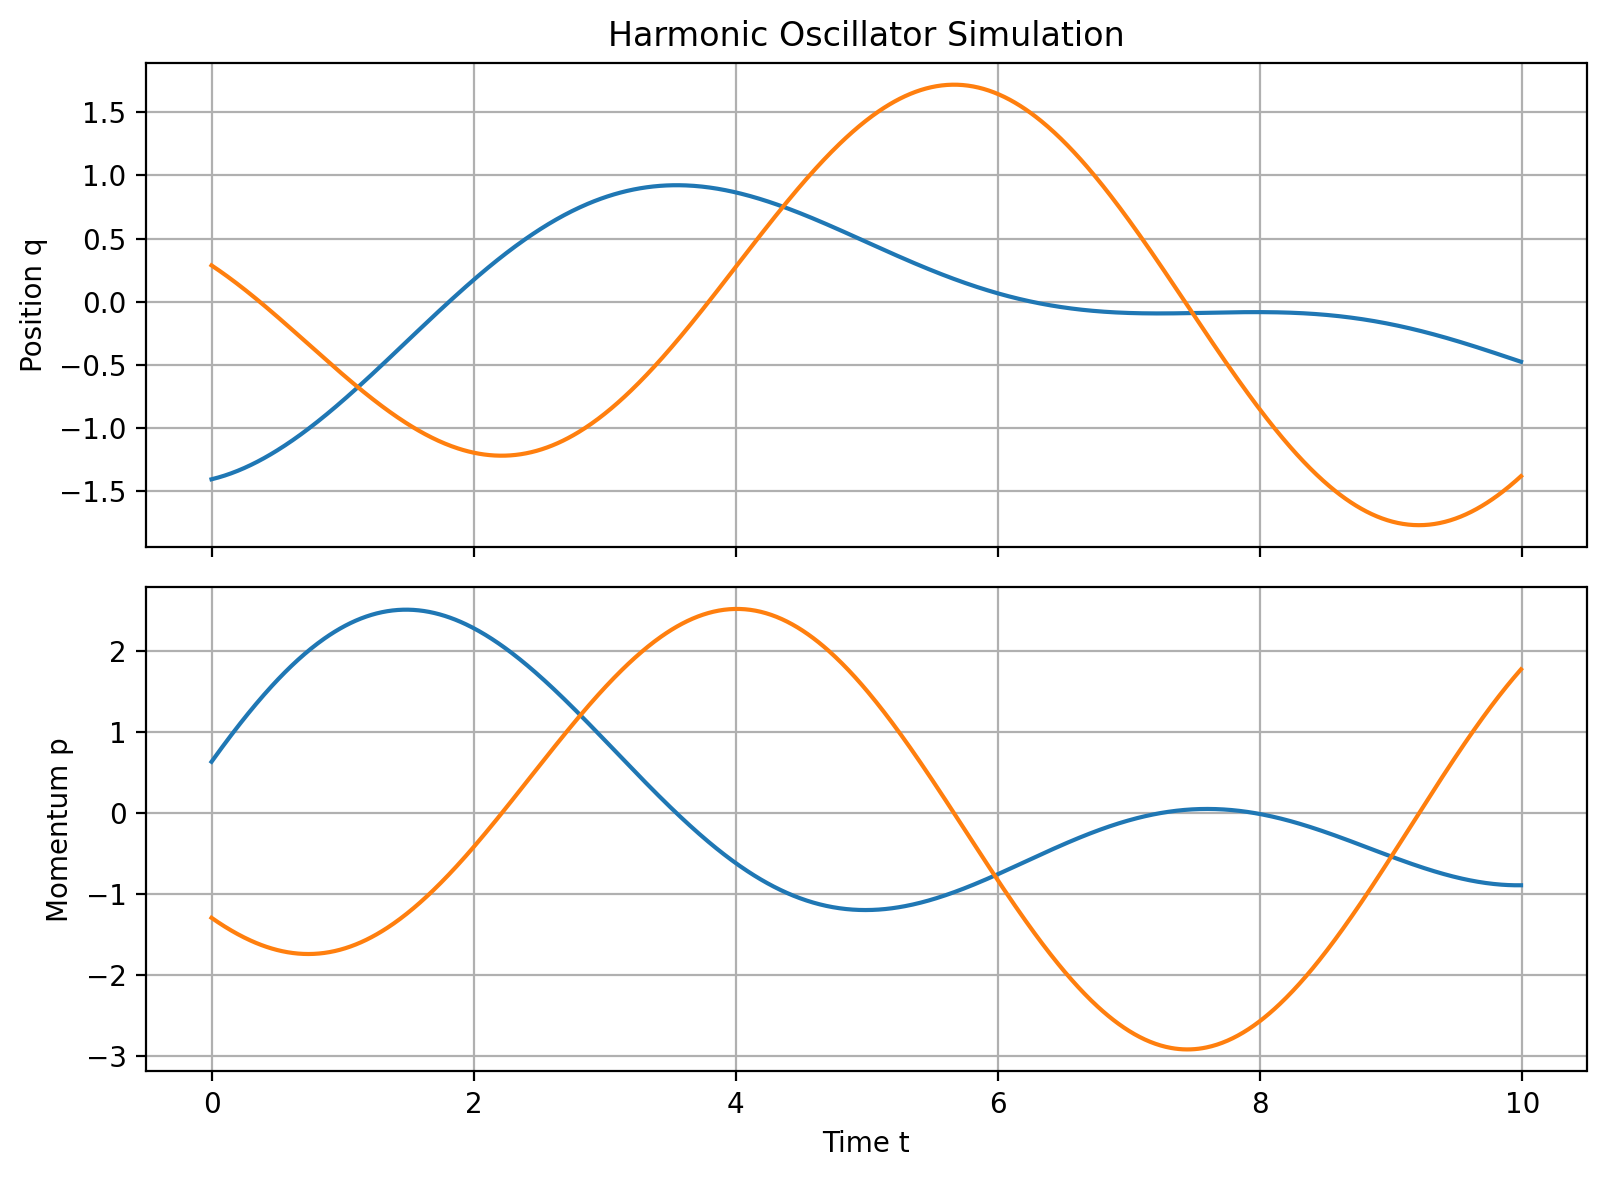

In [150]:
from matplotlib import pyplot as plt

# plot q and p
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax[0].plot(t, q)
ax[0].set_ylabel('Position q')
ax[0].set_title('Harmonic Oscillator Simulation')
ax[0].grid()
ax[1].plot(t, p)
ax[1].set_ylabel('Momentum p')
ax[1].set_xlabel('Time t')
ax[1].grid()
plt.tight_layout()
plt.show()

In [151]:
print(f"m: {hyper_params.m}")
print(f"k_wall: {hyper_params.k_wall}")
print(f"k_pair: {hyper_params.k_pair}")

m: [2.5479121  1.87775688]
k_wall: 1.0
k_pair: 0.5


In [153]:
hyper_params

HarmonicParams(n=2, m=array([2.5479121 , 1.87775688]), k_wall=1.0, k_pair=0.5, A_modes=array([1.85859792, 1.69736803]), phi_modes=array([0.59173373, 6.13001603]))

In [152]:
rng = np.random.default_rng(42)
print( rng.uniform(*(1.0, 3.0), size=(n,)).astype(np.float64))

[2.5479121  1.87775688]


# Rewite classes
To sample multiple initial values, we first rewirte the code into varialbe initial values.

First, let's sample $m$, $k_{\text{wall}}$ and $k_{\text{pair}}$.

In [122]:
m = hyper_params.m
k_wall = hyper_params.k_wall
k_pair = hyper_params.k_pair

In [123]:
# seed = 42
# rng = np.random.default_rng(seed)
# m = rng.uniform(*(1.0, 3.0), size=(n,)).astype(np.float64)
# k_wall = 0.01
# k_pair = 0.005

In [124]:

@dataclass
class HarmonicParamsSInitVal:
    n: int
    m: np.ndarray         # (n,) masses per oscillator
    k_wall: float         # wall spring constant
    k_pair: float         # pairwise coupling spring constant
    # A_modes: np.ndarray   # (n,) amplitudes per normal mode
    # phi_modes: np.ndarray # (n,) phases per normal mode (radians)

def set_harmonic_params(
    n: int,
    m: Tuple[float, float] = (1.0, 3.0),
    k_wall: float = 0.01,
    k_pair: float = 0.005,    
) -> HarmonicParamsSInitVal:
    # Normal-mode amplitudes/phases
    # A_modes = rng.uniform(*A_range, size=(n,)).astype(np.float64)
    # phi_modes = rng.uniform(0.0, 2*np.pi, size=(n,)).astype(np.float64)
    return HarmonicParamsSInitVal(
        n=n, m=m, k_wall=float(k_wall), k_pair=float(k_pair),
        # A_modes=A_modes, phi_modes=phi_modes
    )

def harmonic_hamiltonian(q: np.ndarray, p: np.ndarray, params: HarmonicParamsSInitVal) -> float:
    """
    q, p: (B, n)
    """
    n = params.n
    V_wall = 0.5 * params.k_wall * np.sum(q**2, axis=1)  # (B,)
    V_pair = 0.5 * params.k_pair * ((np.sum(q, axis=1)**2 - np.sum(q**2, axis=1))/2.0)  # (B,)
    V = V_wall + V_pair # (B,)
    T = 0.5 * np.sum((p**2) / params.m, axis=1)  # (B,)
    H = T + V
    return float(H)


def harmonic_hamiltonian_jax(q: jnp.ndarray, p: jnp.ndarray, params: HarmonicParamsSInitVal) -> jnp.ndarray:
    """
    q, p: (B, n)  -> returns (B,)
    NOTE: m を jnp に変換して計算
    """
    if isinstance(params, dict):
        m = jnp.asarray(params["m"])
        k_wall = jnp.asarray(params["k_wall"])
        k_pair = jnp.asarray(params["k_pair"])
    else:
        m = jnp.asarray(params.m)
        k_wall = jnp.asarray(params.k_wall)
        k_pair = jnp.asarray(params.k_pair)
    V_wall = 0.5 * k_wall * jnp.sum(q**2, axis=1)  # (B,)
    V_pair = 0.5 * k_pair * (
        (jnp.sum(q, axis=1) ** 2 - jnp.sum(q**2, axis=1)) / 2.0
    )
    T = 0.5 * jnp.sum((p**2) / m, axis=1)  # (B,)
    return T + V_wall + V_pair  # (B,)

def equation_of_motion(q: jnp.ndarray, p: jnp.ndarray, params: HarmonicParamsSInitVal) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """
    Returns the time derivatives of the positions and momenta.
    """
    dqdt = p / params.m[None, :]  # (B, n)
    I = np.eye(n)
    J = np.ones((n, n))
    L = -(params.k_wall + n * params.k_pair) * I + params.k_pair * J
    dpdt = jnp.matmul(q, jnp.asarray(L).T)  # (B, n)
    #dpdt = -jnp.gradient(harmonic_hamiltonian_jax(q, p, params), axis=1)  # (B, n)
    return dqdt, dpdt

def _normal_mode_eigendecomposition(params: HarmonicParamsSInitVal):
    """
    Returns eigenvalues/eigenvectors for q¨ = M^{-1} L q.
    Repoに合わせて L = -(k_wall + n*k_pair) I + k_pair 1 1^T を用い、
    固有値は負になる（w = sqrt(-eigvals)）。
    """
    n = params.n
    I = jnp.eye(n)
    J = jnp.ones((n, n))
    L = -(params.k_wall + n * params.k_pair) * I + params.k_pair * J
    M_sqrt_inv = jnp.diag(1.0 / jnp.sqrt(params.m))

    # 対称化
    S = M_sqrt_inv @ L @ M_sqrt_inv
    eigvals, U = jnp.linalg.eigh(S)              # 決定的になりやすい
    V = M_sqrt_inv @ U                          # 元の一般化固有ベクトルへ
    return eigvals.real, V.real                 # (n,), (n,n)

    # M_inv = np.diag(1.0 / params.m)
    # M_inv_L = M_inv @ L
    # eigvals, eigvecs = np.linalg.eig(M_inv_L)
    # eigvals = eigvals.real
    # eigvecs = eigvecs.real
    # return eigvals, eigvecs  # (n,), (n,n)

def initial_modes_from_qp(q0, p0, m, V, w, eps=1e-12):
    """
    q0, p0: (n,)
    m: (n,), V: (n,n) with columns = mode vectors (your aux["eigvecs"])
    w: (n,) angular frequencies
    returns: A_modes (n,), phi_modes (n,)
    """
    M = jnp.diag(jnp.asarray(m))
    q0 = jnp.asarray(q0); p0 = jnp.asarray(p0)
    V = jnp.asarray(V);   w  = jnp.asarray(w)

    q_mode0   = V.T @ (M @ q0)        # shape (n,)
    qdot_mode0= V.T @ p0              # since p = M qdot

    # handle near-zero frequencies safely
    w_safe = jnp.where(w < eps, eps, w)

    A = jnp.sqrt(q_mode0**2 + (qdot_mode0 / w_safe)**2)
    phi = jnp.arctan2(-qdot_mode0 / w_safe, q_mode0)

    # (optional) if you truly have zero-frequency modes (e.g., k_wall=0),
    # their motion is linear in time and (A, phi) is not well-defined.
    # You can mark them, or set (A, phi) via a convention:
    zero_mask = (w < eps)
    # e.g., keep A = |q_mode0|, phi = 0 for zeros (or any consistent choice)
    A = jnp.where(zero_mask, jnp.abs(q_mode0), A)
    phi = jnp.where(zero_mask, 0.0, phi)

    return A, phi


def simulate_coupled_1d_harmonic_init_values(
    params: HarmonicParamsSInitVal,
    num_steps: int,
    dt: float,
    q0: jnp.ndarray,
    p0: jnp.ndarray
) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray, Dict]:
    """
    Returns:
      t: (T,)
      q: (T, n) positions
      p: (T, n) momenta  (p = m * dq/dt)
      aux: dict with eigvals/eigvecs/w
    """
    n = params.n
    t = jnp.arange(num_steps, dtype=jnp.float64) * float(dt)

    # Normal modes
    eigvals, V = _normal_mode_eigendecomposition(params)
    w = jnp.sqrt(jnp.clip(-eigvals, a_min=0.0, a_max=None))  # angular freq

    # compute A_modes, phi_modes from (q0, p0)
    M = jnp.diag(jnp.asarray(m))
    q_mode0   = V.T @ (M @ q0)        # shape (n,)
    qdot_mode0= V.T @ p0              # since p = M qdot

    # # handle near-zero frequencies safely
    # w_safe = jnp.where(w < eps, eps, w)

    A = jnp.sqrt(q_mode0**2 + (qdot_mode0 / w)**2)
    phi = jnp.arctan2(-qdot_mode0 / w, q_mode0)

    # Mode-space trajectories
    Wt_phi = t[:, None] * w[None, :] + phi[None, :]  # (T, n)
    q_mode = A[None, :] * jnp.cos(Wt_phi)              # (T, n)
    qdot_mode = -A[None, :] * (w[None, :]) * jnp.sin(Wt_phi)  # (T, n)

    # Map back to physical coords: q = V q_mode, qdot = V qdot_mode
    q = q_mode @ V.T
    qdot = qdot_mode @ V.T
    p = qdot * params.m[None, :]  # momentum = m * qdot

    aux = {"eigvals": eigvals, "eigvecs": V, "w": w}
    return t, q, p, aux

def flow_coupled_1d_harmonic_init_values(
    params: HarmonicParamsSInitVal,
    num_steps: tuple[int, ...],
    dt: float,
    q0: jnp.ndarray,
    p0: jnp.ndarray
) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray, Dict]:
    """
    Returns:
      t: tuple with B integers, times for each batch
      q0: (B, n) positions for each batch
      p0: (B, n) momenta  (p = m * dq/dt) for each batch
      aux: dict with eigvals/eigvecs/w
    """
    n = params.n
    # t = jnp.arange(num_steps, dtype=jnp.float64) * float(dt)
    t = jnp.array([ns * float(dt) for ns in num_steps], dtype=jnp.float64) # shape (B,)

    # Normal modes
    eigvals, V = _normal_mode_eigendecomposition(params)
    w = jnp.sqrt(jnp.clip(-eigvals, a_min=0.0, a_max=None))  # (n,) angular freq

    # compute A_modes, phi_modes from (q0, p0)
    M = jnp.diag(jnp.asarray(params.m)) # (n,n)
    # M_inv = jnp.diag(jnp.asarray(1. / params.m)) # (n,n)
    q_mode0   = (q0 @ M) @ V    # elementwis
    qdot_mode0= p0 @ V              # since p = M qdot

    # q_mode0   = V.T @ (M @ q0)        # shape (n,)
    # qdot_mode0= V.T @ p0              # since p = M qdot

    # # handle near-zero frequencies safely
    # w_safe = jnp.where(w < eps, eps, w)

    A = jnp.sqrt(q_mode0**2 + (qdot_mode0 / w)**2) # (B,n)
    phi = jnp.arctan2(-qdot_mode0 / w, q_mode0)    # (B,n)

    # Mode-space trajectories
    wt_phi = t[:, None] * w[None, :] + phi    # (B, n)
    q_mode = A * jnp.cos(wt_phi)              # (B, n)
    qdot_mode = -A * (w[None, :]) * jnp.sin(wt_phi)  # (B, n)

    # Map back to physical coords: q = V q_mode, qdot = V qdot_mode
    q = q_mode @ V.T
    qdot = qdot_mode @ V.T
    p = qdot * params.m[None, :]  # momentum = m * qdot

    aux = {"eigvals": eigvals, "eigvecs": V, "w": w}
    return t, q, p, aux


## test & debug

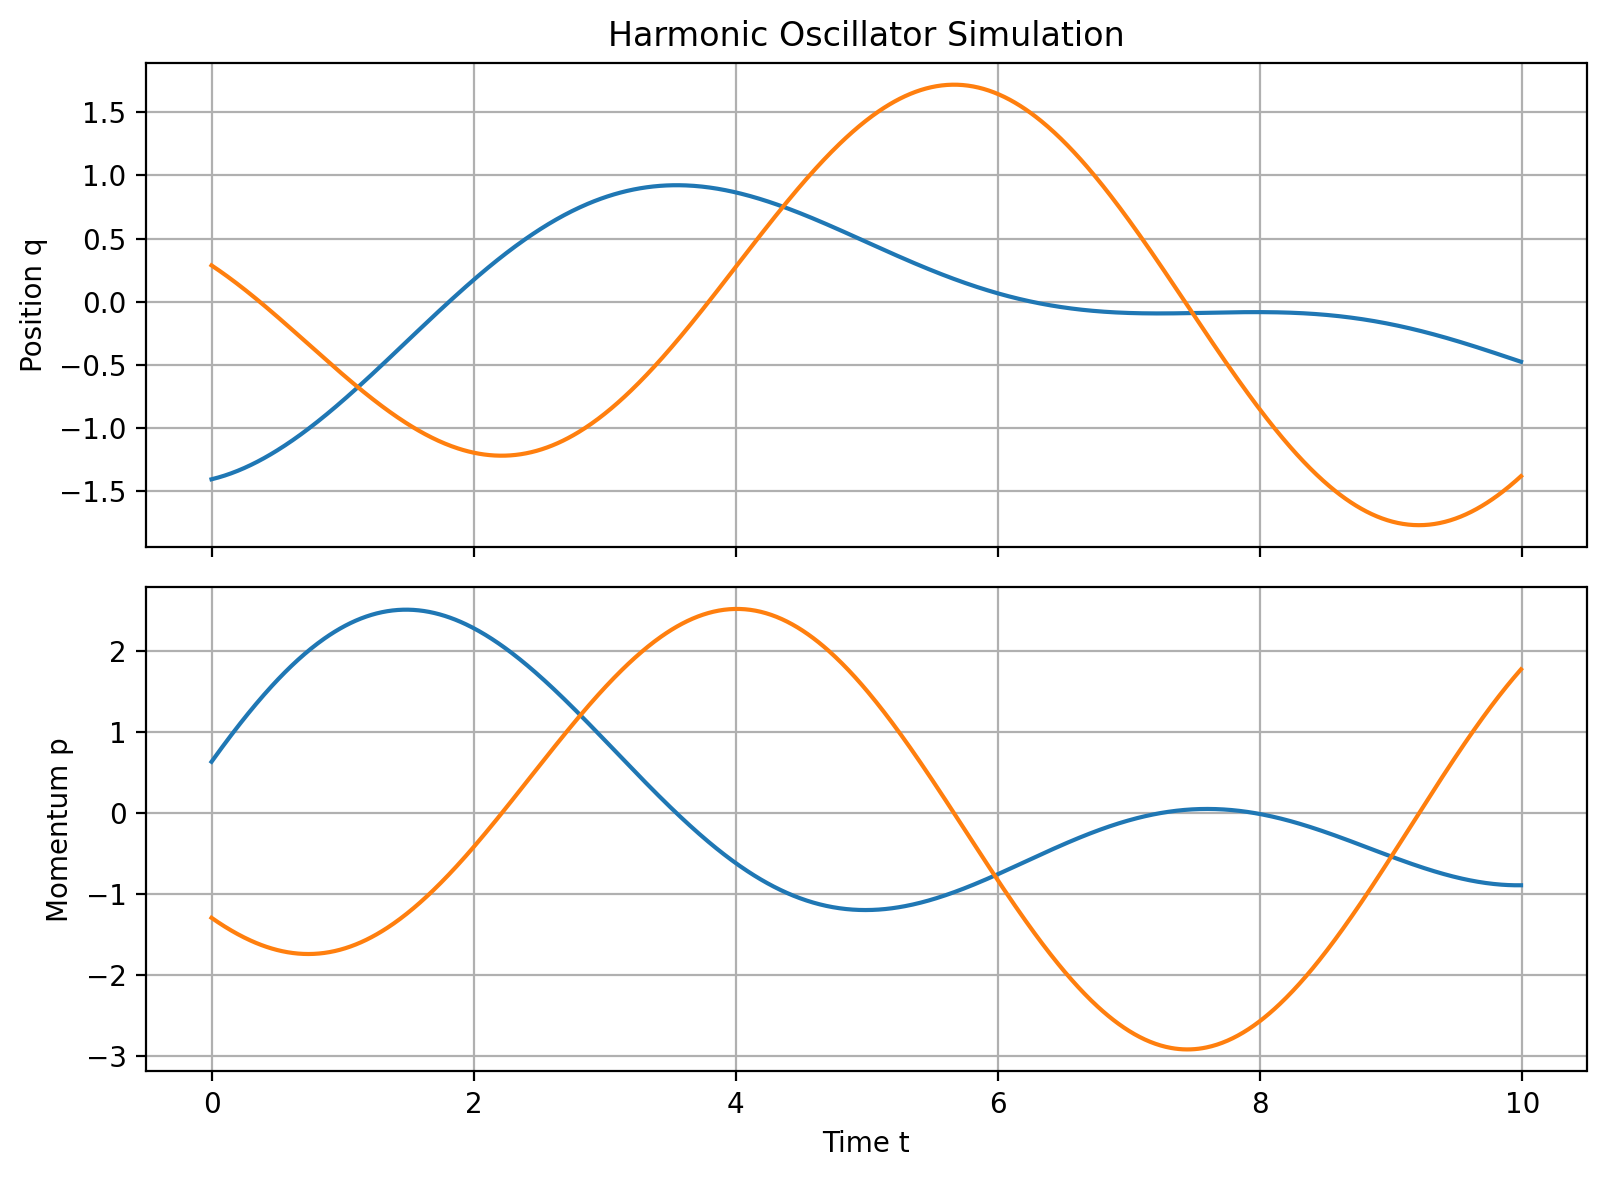

In [125]:

# plot q and p
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax[0].plot(t_orig, q_orig)
ax[0].set_ylabel('Position q')
ax[0].set_title('Harmonic Oscillator Simulation')
ax[0].grid()
ax[1].plot(t_orig, p_orig)
ax[1].set_ylabel('Momentum p')
ax[1].set_xlabel('Time t')
ax[1].grid()
plt.tight_layout()
plt.show()

In [126]:

B = 1000
Ts = tuple(np.arange(0, 1000).tolist())
#Ts = tuple(np.random.randint(500, 1500, size=(B,)).tolist())
t, q, p, aux = flow_coupled_1d_harmonic_init_values(
    params=set_harmonic_params(n=2, m=m, k_wall=k_wall, k_pair=k_pair),
    num_steps=Ts,
    dt=0.01,
    q0=q_orig[0],
    p0=p_orig[0]
)



/tmp/1005822.2871/ipykernel_106098/3765267277.py:186: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  t = jnp.array([ns * float(dt) for ns in num_steps], dtype=jnp.float64) # shape (B,)


In [ ]:
q

In [127]:
k_wall

1.0

In [128]:
k_pair

0.5

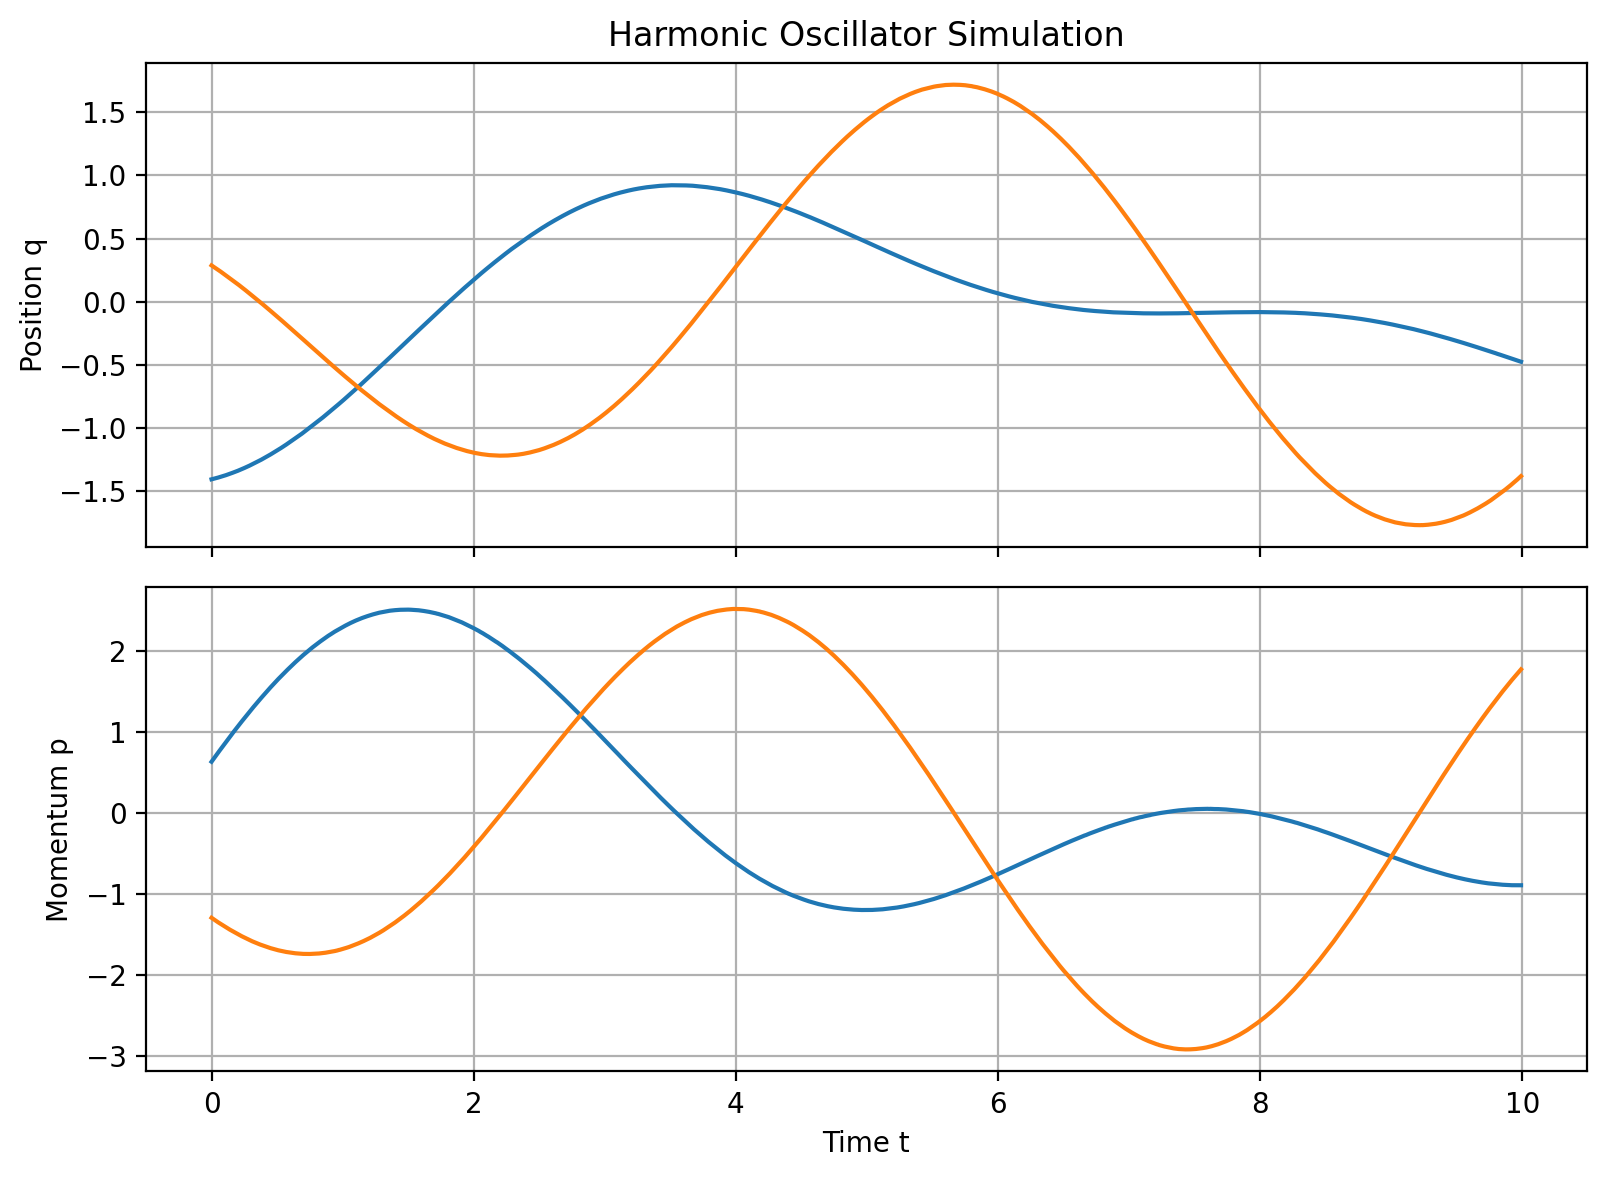

In [129]:
# plot q and p
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax[0].plot(t, q)
ax[0].set_ylabel('Position q')
ax[0].set_title('Harmonic Oscillator Simulation')
ax[0].grid()
ax[1].plot(t, p)
ax[1].set_ylabel('Momentum p')
ax[1].set_xlabel('Time t')
ax[1].grid()
plt.tight_layout()
plt.show()

In [130]:
jnp.linalg.norm(q_orig - q) / jnp.linalg.norm(q_orig)

Array(0.00025857, dtype=float32)

In [131]:
q_orig.shape

(1000, 2)

In [132]:
jnp.linalg.norm(p_orig - p) / jnp.linalg.norm(p_orig)

Array(0.0002873, dtype=float32)

In [133]:
jnp.linalg.norm(t_orig - t) / jnp.linalg.norm(t_orig)

Array(0., dtype=float32)

# Prepare the dataset
Here we settle up the dataset for training. Let $x=(q, p) \in X,\; \dot{x} = (\dot{q}, \dot{p})$, and the flow $\varphi_t: X \to X$ follow $\dot{x} = J\nabla_xH$. We define the dataset $\mathcal{D}$ as
\begin{equation}
\mathcal{D} = \{(x_0, \dot{x}_0, x(t), t) \mid x_0 \in X,\; \dot{x}_0 = J\nabla H(x_0),\; x(t) = \varphi_t(x),\; t\in\mathbb{R}_{>0}\}.
\end{equation}

To create such a dataset (technically, a finite subset of the dataset define above), we sample 
+ $x_0$ from a compact set
+ $t$ with an upper bount $t_{\text{max}}$


In [134]:
def create_dataset(x0, t, dt=dt, hyper_params=hyper_params):
    """
    x0: (B, 2n) initial conditions
    t: (B,) time steps for each batch
    Returns:
    x0: (B, 2n)
    x0_dot: (B, 2n)
    xt: (B, 2n)
    t: (B,)
    """
    B, dim = x0.shape
    n = dim // 2
    q0 = x0[:, :n]
    p0 = x0[:, n:]

    t, q, p, _ = flow_coupled_1d_harmonic_init_values(
        params=set_harmonic_params(n=n, m=hyper_params.m, k_wall=hyper_params.k_wall, k_pair=hyper_params.k_pair),
        num_steps=tuple(t.tolist()),
        dt=dt,
        q0=q0,
        p0=p0
    )
    xt = jnp.concatenate([q, p], axis=1)  # (B, 2n)

    # compute x0_dot
    dqdt0 = p0 / hyper_params.m[None, :]  # (B, n)
    I = np.eye(n)
    J = np.ones((n, n))
    L = -(hyper_params.k_wall + n * hyper_params.k_pair) * I + hyper_params.k_pair * J
    dpdt0 = jnp.matmul(q0, jnp.asarray(L).T)  # (B, n)
    x0_dot = jnp.concatenate([dqdt0, dpdt0], axis=1)  # (B, 2n)

    return x0, x0_dot, xt, t
    

In [135]:
N_train = 10000
N_test  = 2500
delta_t_max = 10.0
train_t_dist = "uniform" # "uniform", "step_scheduling"

key = jax.random.PRNGKey(0)
q0_train = jax.random.uniform(key, shape=(N_train, n), minval=-3.0, maxval=3.0)
p0_train = jax.random.uniform(key, shape=(N_train, n), minval=-3.0, maxval=3.0)

if train_t_dist == "uniform":
    
    delta_t_train = jnp.clip(
        dt * jax.random.randint(key, shape=(N_train,), minval=1, maxval=delta_t_max),
        min=dt,
        max=delta_t_max
    )
elif train_t_dist == "step_scheduling":
    unif_vec = jax.random.uniform(key, shape=(N_train,), minval=0.0, maxval=1.0)
    delta_t_train = jnp.clip(
        dt * jnp.ceil( unif_vec * ((delta_t_max * jnp.arange(N_train)/N_train)//dt)),
        min=dt,
        max=delta_t_max
    )

q0_test = jax.random.uniform(key, shape=(N_test, n), minval=-3.0, maxval=3.0)
p0_test = jax.random.uniform(key, shape=(N_test, n), minval=-3.0, maxval=3.0)
delta_t_test = jax.random.uniform(key, shape=(N_test,), minval=0.01, maxval=30.0)

train_dataset = create_dataset(
    x0=jnp.concatenate([q0_train, p0_train], axis=1),
    t=delta_t_train,
    dt=dt,
    hyper_params=hyper_params
)
test_dataset = create_dataset(
    x0=jnp.concatenate([q0_test, p0_test], axis=1),
    t=delta_t_test,
    dt=dt,
    hyper_params=hyper_params
)

/tmp/1005822.2871/ipykernel_106098/3765267277.py:186: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  t = jnp.array([ns * float(dt) for ns in num_steps], dtype=jnp.float64) # shape (B,)


In [136]:
key = jax.random.PRNGKey(0)
N_train = 10000
N_test  = 2500
delta_t_max = 10.0
unif_vec = jax.random.uniform(key, shape=(N_train,), minval=0.0, maxval=1.0)
delta_t_train = jnp.clip(
    dt * jnp.ceil( unif_vec * ((delta_t_max * jnp.arange(N_train)/N_train)//dt)),
    min=dt,
    max=delta_t_max
)
print(delta_t_train)

[0.01 0.01 0.01 ... 3.83 4.92 6.46]


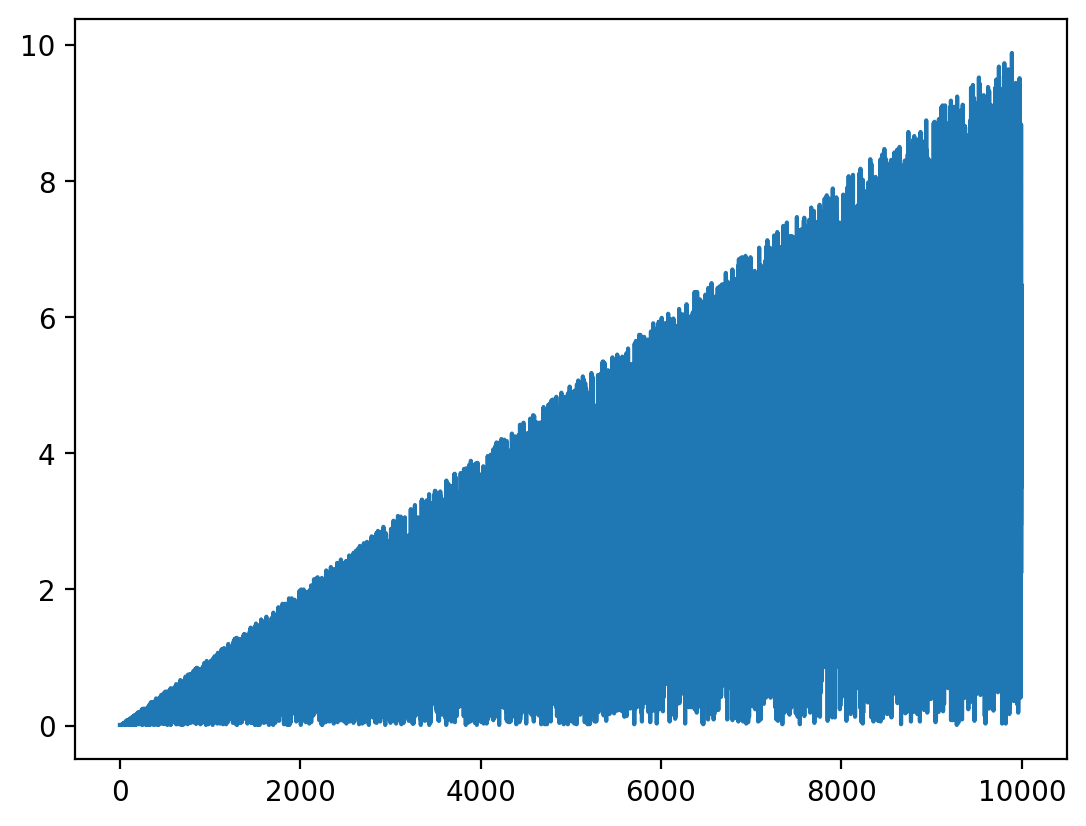

In [137]:
from matplotlib import pyplot as plt
#plt.hist(delta_t_train, bins=50)
plt.plot(delta_t_train)

In [138]:
jax.random.rand(key, shape=(3,), minval=1, maxval=10)

AttributeError: module 'jax.random' has no attribute 'rand'

# Build model & train

In [139]:
model = MyActionAngleNetwork(
    dim_config=n,
    dim_hidden_list=[32, 32, 32],
    num_gsblocks=20,
    type_polar="canonical",
    activation=nn.silu,
    mlp_res_connection=False,
    theta_predictor="gradient",
)


In [140]:
rng = jax.random.PRNGKey(0)
q0 = jnp.zeros((1, int(n)))
p0 = jnp.zeros((1, int(n)))
delta_t0 = jnp.asarray(0.1)

variables = model.init(rng, q0, p0, delta_t0)
params = variables['params']
num_params = sum(jax.tree_util.tree_leaves(jax.tree_util.tree_map(lambda x: x.size, params)))
print(f'Total parameters: {num_params}')


Total parameters: 7441


# Training

In [141]:
# --- New helper: batched ∂H/∂q, ∂H/∂p ---
# def H_gt_grad_batch(q: jnp.ndarray, p: jnp.ndarray, gt_params):
#     """
#     q, p: (B, n) -> dHdq, dHdp each (B, n)
#     """
#     def Hsum(q, p):
#         return harmonic_hamiltonian_jax(q, p, gt_params).sum()

#     dHdq, dHdp = jax.grad(Hsum, argnums=(0, 1))(q, p)
#     return dHdq, dHdp


def train_step(params, opt_state, dtst_batch, apply_fn, tx,
               loss_weights=(1.0, 1.0, 0.0, 1.0)):
    x, x_dot, y, delta_t = dtst_batch  # x, x_dot, y: (B, 2n), delta_t: (B,)    
    
    n = x.shape[1] // 2
    q, p = x[:, :n], x[:, n:]  # (B, n), (B, n)
    q_dot, p_dot = x_dot[:, :n], x_dot[:, n:]

    # dHdq_gt, dHdp_gt = H_gt_grad_batch(q, p, gt_params)

    # def H_hat_single(pp, qi, pi):
    #     return apply_fn({'params': pp}, qi[None, :], pi[None, :],
    #                     method=model.hamiltonian).squeeze()

    # grad_q_H_hat_single = jax.grad(H_hat_single, argnums=1)
    # grad_p_H_hat_single = jax.grad(H_hat_single, argnums=2)
    # dHdq_model = jax.vmap(lambda qi, pi: grad_q_H_hat_single(params, qi, pi))(q, p)
    # dHdp_model = jax.vmap(lambda qi, pi: grad_p_H_hat_single(params, qi, pi))(q, p)

    def loss_fn(pp):
        q_, p_, I, _ = apply_fn({'params': pp}, q, p, delta_t, train=True)

        loss_q_se = ((q_ - y[:, :n]) ** 2).mean()
        loss_p_se = ((p_ - y[:, n:]) ** 2).mean()

        def H_hat_single(qi, pi):
            return apply_fn({'params': pp}, qi[None, :], pi[None, :],
                            method=model.hamiltonian).squeeze()

        dHdq_model = jax.vmap(lambda qi, pi: jax.grad(H_hat_single, argnums=0)(qi, pi))(q, p)
        dHdp_model = jax.vmap(lambda qi, pi: jax.grad(H_hat_single, argnums=1)(qi, pi))(q, p)

        L_HNN = ((dHdq_model + p_dot) ** 2).mean() + ((dHdp_model - q_dot) ** 2).mean()

        L_action = lax.cond(
            loss_weights[2] > 0.0,
            lambda I: jnp.var(I, axis=0).sum(),
            lambda I: 0.0,
            I
        )
        # if (loss_weights[2] > 0.0):
        #     L_action = jnp.var(I, axis=0).sum()
        # else:
        #     L_action = 0.0

        return (loss_weights[0] * loss_q_se +
                loss_weights[1] * loss_p_se +
                loss_weights[2] * L_action +
                loss_weights[3] * L_HNN)
        #return loss_q_se + loss_p_se + alpha * L_action + beta * L_HNN

    loss, grads = value_and_grad(loss_fn)(params)
    updates, opt_state = tx.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss


train_step_jit = jax.jit(train_step, static_argnames=('apply_fn', 'tx'))


In [142]:
@partial(jax.jit, static_argnames=('apply_fn',))
def eval_batch(params, x, y, delta_t, *, apply_fn):
    n = x.shape[1] // 2
    q, p = x[:, :n], x[:, n:]

    q_, p_, _, _ = apply_fn({'params': params}, q, p, delta_t, train=False)

    loss_q_mse = ((q_ - y[:, :n]) ** 2).mean()
    loss_p_mse = ((p_ - y[:, n:]) ** 2).mean()

    return loss_q_mse + loss_p_mse


In [143]:
# --- Replace: 学習ループの該当部分 ---
seed = 201
lr = 1e-3
batch_size = 100
epoch = 1
ep_shuffle_chunks = 4

log_every = 20
loss_weights = (1.0, 1.0, 0.0, 1.0)
delta_t = dt  # base time step
delta_t_max = 10.0  # max jump multiplier during training


key = jax.random.PRNGKey(seed)
variables = model.init(key, jnp.zeros((1, n)), jnp.zeros((1, n)), jnp.asarray(dt))
nn_params = variables['params']

tx = optax.adam(learning_rate=lr)
opt_state = tx.init(nn_params)

idx_serial_batch = 0

for ep in range(epoch):
    
    if ep == 0:
        x0_train, x0_dot_train, xt_train, t_train = train_dataset
    else:
        # Shuffle training data
        # なんとなくtを最初の方は短く→あとで長くとトレーニングしたいので、何チャンクかにわけてそのチャンク内でシャッフル
        # epoch=1なら関係ない
        for idx_ep in range(ep_shuffle_chunks):
            perm_key, key = jax.random.split(key)
            perm = jax.random.permutation(perm_key, N_train // ep_shuffle_chunks)
            start_idx = idx_ep * (N_train // ep_shuffle_chunks)
            end_idx = (idx_ep + 1) * (N_train // ep_shuffle_chunks)
            x0_train, x0_dot_train, xt_train, t_train = train_dataset
            x0_train = x0_train.at[start_idx:end_idx].set(x0_train[start_idx:end_idx][perm])
            x0_dot_train = x0_dot_train.at[start_idx:end_idx].set(x0_dot_train[start_idx:end_idx][perm])
            xt_train = xt_train.at[start_idx:end_idx].set(xt_train[start_idx:end_idx][perm])
            t_train = t_train.at[start_idx:end_idx].set(t_train[start_idx:end_idx][perm])
    
    # Mini-batch training
    num_batches = N_train // batch_size
    epoch_loss = 0.0

    for i in range(num_batches):
        batch_x0 = x0_train[i*batch_size:(i+1)*batch_size]
        batch_x0_dot = x0_dot_train[i*batch_size:(i+1)*batch_size]
        batch_xt = xt_train[i*batch_size:(i+1)*batch_size]
        batch_t = t_train[i*batch_size:(i+1)*batch_size]

        nn_params, opt_state, batch_loss = train_step_jit(
            nn_params, opt_state,
            (batch_x0, batch_x0_dot, batch_xt, batch_t),
            apply_fn=model.apply, tx=tx,
            loss_weights=loss_weights
        )
        total_batch_loss = batch_loss * len(batch_t)
        epoch_loss += total_batch_loss
        #epoch_loss += batch_loss * 

        idx_serial_batch += 1

        if (idx_serial_batch + 1) % log_every == 0:
            print(f"Epoch {ep+1}, Batch {i+1}/{num_batches}, Loss: {batch_loss:.6f}")

        if (idx_serial_batch) % log_every == 0 or idx_serial_batch == 1 or (ep==epoch-1 and i==num_batches-1):
            test_losses = []
            num_test_batches = N_test // batch_size
            for j in range(num_test_batches):
                batch_x0_test = test_dataset[0][j*batch_size:(j+1)*batch_size]
                batch_x0_dot_test = test_dataset[1][j*batch_size:(j+1)*batch_size]
                batch_xt_test = test_dataset[2][j*batch_size:(j+1)*batch_size]
                batch_t_test = test_dataset[3][j*batch_size:(j+1)*batch_size]

                test_loss = eval_batch(
                    nn_params,
                    batch_x0_test,
                    batch_xt_test,
                    batch_t_test,
                    apply_fn=model.apply
                )
                test_losses.append(test_loss * len(batch_t_test))
            total_test_loss = sum(test_losses) / N_test
            print(f"*** Test Loss after {idx_serial_batch} batches: {total_test_loss:.6f} ***")

    epoch_loss /= N_train
    print(f"Epoch {ep+1} completed. Average Loss: {epoch_loss:.6f}")

    


2025-10-31 07:46:57.411185: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-10-31 07:46:57.411221: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-10-31 07:46:57.411281: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-10-31 07:46:57.411293: W external/xla/xla/service/gpu/au

*** Test Loss after 1 batches: 261372.000000 ***
Epoch 1, Batch 19/100, Loss: 347295.437500
*** Test Loss after 20 batches: 7787.272461 ***
Epoch 1, Batch 39/100, Loss: 185092.671875
*** Test Loss after 40 batches: 7719.846191 ***
Epoch 1, Batch 59/100, Loss: 226248.734375
*** Test Loss after 60 batches: 7232.673340 ***
Epoch 1, Batch 79/100, Loss: 290265.937500
*** Test Loss after 80 batches: 5882.734375 ***
Epoch 1, Batch 99/100, Loss: 84631.265625
*** Test Loss after 100 batches: 2763.985840 ***
Epoch 1 completed. Average Loss: 567746.125000


In [144]:
# Roll out model predictions from initial state across full horizon

# Convert true series to JAX arrays
q_true = jnp.asarray(q_test)
p_true = jnp.asarray(p_test)
T_total = 100 #int(q_true.shape[0])
n_dim = int(q_true.shape[1])

# Initial state and per-step delta_t
q0_roll = q_true[:1].squeeze(axis=0) if q_true.ndim==2 else q_true[:1]
p0_roll = p_true[:1].squeeze(axis=0) if p_true.ndim==2 else p_true[:1]
delta_t_infer = jnp.asarray(float(dt))

def _step_fn(carry, _):
    q_curr, p_curr = carry
    q_next, p_next, _, _ = model.apply({'params': nn_params}, q_curr, p_curr, delta_t_infer, train=False)
    return (q_next, p_next), (q_next, p_next)

# Rollout T_total-1 steps to get length T_total with the initial appended
(_, _), (qs_seq, ps_seq) = jax.lax.scan(_step_fn, (q0_roll, p0_roll), None, length=max(T_total-1, 0))
q_pred = jnp.concatenate([q0_roll[None,...], qs_seq], axis=0) if T_total>0 else q0_roll
p_pred = jnp.concatenate([p0_roll[None,...], ps_seq], axis=0) if T_total>0 else p0_roll

# Remove batch axis
q_pred = jnp.squeeze(q_pred, axis=1) if q_pred.ndim==3 else q_pred
p_pred = jnp.squeeze(p_pred, axis=1) if p_pred.ndim==3 else p_pred

print('q_pred shape:', q_pred.shape, 'p_pred shape:', p_pred.shape)

t.shape
# Plot true vs predicted trajectories
import matplotlib.pyplot as plt
t_arr = np.asarray(t[:T_total])
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Positions
for i in range(q_pred.shape[1]):
    axes[0].plot(t_arr, np.asarray(q_true)[:T_total, i], label=f'true q[{i}]', alpha=0.7)
    axes[0].plot(t_arr, np.asarray(q_pred)[:, i], '--', label=f'pred q[{i}]', alpha=0.9)
axes[0].set_ylabel('q')
axes[0].grid(True)
axes[0].legend(ncol=2, fontsize=8)

# Momenta
for i in range(p_pred.shape[1]):
    axes[1].plot(t_arr, np.asarray(p_true)[:T_total, i], label=f'true p[{i}]', alpha=0.7)
    axes[1].plot(t_arr, np.asarray(p_pred)[:, i], '--', label=f'pred p[{i}]', alpha=0.9)
axes[1].set_ylabel('p')
axes[1].set_xlabel('time')
axes[1].grid(True)
axes[1].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()


NameError: name 'q_test' is not defined